In [1]:
#　モジュールの読み込み
import requests         #HTTP向けのPythonのライブラリ
import json             #JavaScript言語の表記法をベースにしたデータ形式
import urllib.parse     #URLエンコード・デコードするモジュール
import os               #osをコントロールするモジュール
import sqlite3          #sqliteへのアクセスモジュール
import pandas as pd
import numpy as np
import sqlalchemy as sa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors
import datetime as dt
import random
import math
from scipy import signal
from scipy.stats import norm
from scipy.interpolate import griddata
import pickle



from dotenv import load_dotenv

from langchain.chat_models import ChatOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent


# .env 読み込み
print(r"..\environment\.env")
load_dotenv(dotenv_path=r'..\environment/.env',override=True)

# =========================
# 🔐 Metabase 認証・データ取得
# =========================

login_url = "https://metabase.tr-com.net/api/session"
username = os.getenv("MB_USERNAME", "").strip()
password = os.getenv("MB_PASSWORD", "").strip()

if not username or not password:
    raise ValueError("❌ MB_USERNAME または MB_PASSWORD が設定されていません")

print(f"ログイン試行中 → username: '{username}'")

response = requests.post(login_url, json={"username": username, "password": password})
if response.status_code == 200:
    session_id = response.json().get("id")
    print("✅ ログイン成功")
else:
    raise Exception(f"❌ ログイン失敗: {response.status_code}, {response.text}")


..\environment\.env
ログイン試行中 → username: 'y-nitta@torishima.co.jp'
✅ ログイン成功


In [2]:

# 被駆動機についてるTRCOMデータ取得
url = "https://metabase.tr-com.net/api/card/2184/query/json"
headers = {
    "Content-Type": "application/json",
    "X-Metabase-Session": session_id
}


In [3]:

response = requests.post(url, headers=headers)
if response.status_code == 200:
    try:
        data = response.json()
        dfori = pd.DataFrame(data)
        if dfori.empty:
            raise ValueError("❌ 取得したデータが空です。Metabaseを確認してください。")
        print("✅ データ取得成功")
        print(dfori.head())

    except Exception as e:
        raise Exception(f"❌ データ取得・DataFrame変換失敗: {e}")
else:
    raise Exception(f"❌ データ取得失敗: {response.status_code}, {response.text}")


✅ データ取得成功
   SensorId                               AssetId SensorType Orientation
0  EC001A4A  04d8856f-779b-4eac-989e-dc30484cf560          M           4
1  EC001A72  07c45694-d288-47e6-a8ac-288bdce97062          M           4
2  EC001A7E  9cfd7870-ff4c-406e-aa72-65dfb695c694          M           4
3  EC0020AE  00f07f35-fa5d-4703-a745-edb303666bf6          M           4
4  EC01BD41  8ec208c4-7ff7-468d-9462-b270578ce37f          M           4


In [4]:

# bearingType情報（Value）があるデータ取得
url = "https://metabase.tr-com.net/api/card/2073/query/json"
headers = {
    "Content-Type": "application/json",
    "X-Metabase-Session": session_id
}


In [5]:

response = requests.post(url, headers=headers)
if response.status_code == 200:
    try:
        data = response.json()
        dfbearing = pd.DataFrame(data)
        if dfbearing.empty:
            raise ValueError("❌ 取得したデータが空です。Metabaseを確認してください。")
        print("✅ データ取得成功")
        print(dfbearing.head())

    except Exception as e:
        raise Exception(f"❌ データ取得・DataFrame変換失敗: {e}")
else:
    raise Exception(f"❌ データ取得失敗: {response.status_code}, {response.text}")


✅ データ取得成功
                                AssetId                     ItemId     Value  \
0  00016c44-7fdb-410b-be41-509412376f21   EquipmentDEBearingNumber   7313BDB   
1  00016c44-7fdb-410b-be41-509412376f21  EquipmentNDEBearingNumber   NU313C3   
2  0004484c-e1cd-4b93-99c2-b7f9c5a80448       DriveDEBearingNumber  6309ZZC3   
3  0004484c-e1cd-4b93-99c2-b7f9c5a80448      DriveNDEBearingNumber  6208ZZC3   
4  000861f3-4102-4f45-a223-1c675e380575   EquipmentDEBearingNumber   7318BDT   

            CreateDate  CreateAccountId           UpdateDate  UpdateAccountId  
0  2023-11-17T05:21:47            11441  2023-11-17T05:21:47            11441  
1  2023-11-17T05:21:47            11441  2023-11-17T05:21:47            11441  
2  2024-04-04T02:00:49            18665  2024-04-04T02:00:49            18665  
3  2024-04-04T02:00:49            18665  2024-04-04T02:00:49            18665  
4  2024-08-19T07:11:14            13089  2024-08-19T07:11:14            13089  


In [6]:

# bearingType情報（Value）があるデータ取得
url = "https://metabase.tr-com.net/api/card/2186/query/json"
headers = {
    "Content-Type": "application/json",
    "X-Metabase-Session": session_id
}


In [7]:

response = requests.post(url, headers=headers)
if response.status_code == 200:
    try:
        data = response.json()
        dfspeed = pd.DataFrame(data)
        if dfspeed.empty:
            raise ValueError("❌ 取得したデータが空です。Metabaseを確認してください。")
        print("✅ データ取得成功")
        print(dfspeed.head())

    except Exception as e:
        raise Exception(f"❌ データ取得・DataFrame変換失敗: {e}")
else:
    raise Exception(f"❌ データ取得失敗: {response.status_code}, {response.text}")


✅ データ取得成功
                                AssetId ItemId Value           CreateDate  \
0  000043cd-568e-4b87-84eb-33d4c3484f9c  Speed  3500  2022-06-08T05:37:16   
1  00016c44-7fdb-410b-be41-509412376f21  Speed  1750  2021-08-03T06:13:42   
2  000242a5-9ffd-4ec0-9af1-5b8685a22905  Speed   885  2021-02-08T07:29:47   
3  000861f3-4102-4f45-a223-1c675e380575  Speed  1805  2024-08-19T07:11:14   
4  000c617f-2bdf-4e56-87b1-659f90586ad0  Speed  1470           2018-02-19   

   CreateAccountId           UpdateDate  UpdateAccountId  
0            17294  2023-08-30T06:53:22            16155  
1            11441  2023-11-17T05:21:47            11441  
2            11413  2021-02-08T07:29:47            11413  
3            13089  2024-08-19T07:11:14            13089  
4                1           2018-02-19                1  


In [8]:
dfori

,SensorId,AssetId,SensorType,Orientation
0,EC001A4A,04d8856f-779b-4eac-989e-dc30484cf560,M,4
1,EC001A72,07c45694-d288-47e6-a8ac-288bdce97062,M,4
2,EC001A7E,9cfd7870-ff4c-406e-aa72-65dfb695c694,M,4
3,EC0020AE,00f07f35-fa5d-4703-a745-edb303666bf6,M,4
4,EC01BD41,8ec208c4-7ff7-468d-9462-b270578ce37f,M,4
...,...,...,...,...
22048,XVXP5VB0FEF6513462211AAE3A,913dea24-a67b-4fbd-934d-e17769701627,M,4
22049,XVXP5VB0FEF651346227CE4DD,913dea24-a67b-4fbd-934d-e17769701627,M,4
22050,XVXPVB37D02F1343E3B191E28,a5265ca7-7564-498f-a8d7-2aebdc83c687,M,3
22051,XVXPVB39CFF41343E3B19038B,4773a57d-08bc-4fe0-bfd0-c3c3f7807ec4,M,3


In [9]:
dfori[dfori['AssetId'].duplicated(keep=False)].sort_values(by='AssetId')


,SensorId,AssetId,SensorType,Orientation
6307,VBC3B738,000242a5-9ffd-4ec0-9af1-5b8685a22905,M,4
12975,VC002981,000242a5-9ffd-4ec0-9af1-5b8685a22905,M,4
5899,VBC0EB90,000242a5-9ffd-4ec0-9af1-5b8685a22905,M,4
6207,VBC2EA5F,000242a5-9ffd-4ec0-9af1-5b8685a22905,M,4
14211,VC003173,001004bf-d6d8-464b-a793-580c0d2a500c,M,4
...,...,...,...,...
19666,XVVB69E09F1348A6D2D145D,ffdb09ec-2637-466c-b5cf-b00272a26d63,M,4
19665,XVVB69E09F1348A6C3D818A,ffdb09ec-2637-466c-b5cf-b00272a26d63,M,4
8127,VC000AC1,fff13565-cd3d-46b8-b042-234067ef7207,M,4
2355,VB6903E2,fff13565-cd3d-46b8-b042-234067ef7207,M,4


In [10]:
# AssetId と Orientation のセットで重複している行をまとめて、先頭の1件だけ残す
dfori = dfori.drop_duplicates(subset=['AssetId', 'Orientation'], keep='first')

dfori


,SensorId,AssetId,SensorType,Orientation
0,EC001A4A,04d8856f-779b-4eac-989e-dc30484cf560,M,4
1,EC001A72,07c45694-d288-47e6-a8ac-288bdce97062,M,4
2,EC001A7E,9cfd7870-ff4c-406e-aa72-65dfb695c694,M,4
3,EC0020AE,00f07f35-fa5d-4703-a745-edb303666bf6,M,4
4,EC01BD41,8ec208c4-7ff7-468d-9462-b270578ce37f,M,4
...,...,...,...,...
22040,XVXP2VB0F11AF13463C41470D3,eb08b73a-fc2b-4988-b515-65dccc37642b,M,4
22042,XVXP2VB99C14B13463C416000F,d99f1c08-c465-4270-9166-baffd41efd75,M,4
22043,XVXP3VB0F11AF13463C415D66F,ed7f2c52-4ffd-4abd-a181-4b3b0c89ca63,M,4
22045,XVXP3VB99C14B13463C4174830,26953757-5846-446c-b6e7-88d3d4585afa,M,4


In [11]:
dfbearing

,AssetId,ItemId,Value,CreateDate,CreateAccountId,UpdateDate,UpdateAccountId
0,00016c44-7fdb-410b-be41-509412376f21,EquipmentDEBearingNumber,7313BDB,2023-11-17T05:21:47,11441,2023-11-17T05:21:47,11441
1,00016c44-7fdb-410b-be41-509412376f21,EquipmentNDEBearingNumber,NU313C3,2023-11-17T05:21:47,11441,2023-11-17T05:21:47,11441
2,0004484c-e1cd-4b93-99c2-b7f9c5a80448,DriveDEBearingNumber,6309ZZC3,2024-04-04T02:00:49,18665,2024-04-04T02:00:49,18665
3,0004484c-e1cd-4b93-99c2-b7f9c5a80448,DriveNDEBearingNumber,6208ZZC3,2024-04-04T02:00:49,18665,2024-04-04T02:00:49,18665
4,000861f3-4102-4f45-a223-1c675e380575,EquipmentDEBearingNumber,7318BDT,2024-08-19T07:11:14,13089,2024-08-19T07:11:14,13089
...,...,...,...,...,...,...,...
11340,ffeba098-61b0-4f3b-97dc-56e791d03ba9,EquipmentNDEBearingNumber,6310,2023-03-21T07:00:32,19303,2023-03-21T07:00:32,19303
11341,ffef73d0-e011-49bf-9f19-b20360b5cfdf,DriveDEBearingNumber,6313ZZ,2023-12-18T01:48:32,16511,2023-12-18T01:48:32,16511
11342,ffef73d0-e011-49bf-9f19-b20360b5cfdf,DriveNDEBearingNumber,6311ZZ,2023-12-18T01:48:32,16511,2023-12-18T01:48:32,16511
11343,fffd8640-235e-46c4-8490-ff91aa7eef49,EquipmentDEBearingNumber,6330,2018-02-19,1,2018-02-19,1


In [12]:
dfbearing[dfbearing.duplicated(subset=['AssetId','ItemId', 'Value'], keep=False)].sort_values(by='ItemId')


,AssetId,ItemId,Value,CreateDate,CreateAccountId,UpdateDate,UpdateAccountId


In [13]:
# 対応表で Orientation を追加
itemid_to_orientation = {
    'EquipmentDEBearingNumber': '1',
    'EquipmentNDEBearingNumber': '2',
    'DriveDEBearingNumber': '3',
    'DriveNDEBearingNumber': '4'
}

# Orientation列を追加し、str型として扱う
dfbearing['Orientation'] = dfbearing['ItemId'].map(itemid_to_orientation)

# 対応外を除外
dfbearing_filtered = dfbearing.dropna(subset=['Orientation'])

# dforiのOrientationもstr型に統一
dfori['Orientation'] = dfori['Orientation'].astype(str)

# マージ（AssetId + Orientation）
merged_df = pd.merge(
    dfbearing_filtered,
    dfori,
    on=['AssetId', 'Orientation'],
    how='inner'
)

print("マージ後件数:", len(merged_df))


マージ後件数: 2418


C:\Users\H6445\AppData\Local\Temp\ipykernel_10232\759346807.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfori['Orientation'] = dfori['Orientation'].astype(str)


In [14]:
dfspeed

,AssetId,ItemId,Value,CreateDate,CreateAccountId,UpdateDate,UpdateAccountId
0,000043cd-568e-4b87-84eb-33d4c3484f9c,Speed,3500,2022-06-08T05:37:16,17294,2023-08-30T06:53:22,16155
1,00016c44-7fdb-410b-be41-509412376f21,Speed,1750,2021-08-03T06:13:42,11441,2023-11-17T05:21:47,11441
2,000242a5-9ffd-4ec0-9af1-5b8685a22905,Speed,885,2021-02-08T07:29:47,11413,2021-02-08T07:29:47,11413
3,000861f3-4102-4f45-a223-1c675e380575,Speed,1805,2024-08-19T07:11:14,13089,2024-08-19T07:11:14,13089
4,000c617f-2bdf-4e56-87b1-659f90586ad0,Speed,1470,2018-02-19,1,2018-02-19,1
...,...,...,...,...,...,...,...
7057,ffeba098-61b0-4f3b-97dc-56e791d03ba9,Speed,2975,2023-03-21T07:00:32,19303,2023-03-21T07:00:32,19303
7058,ffecef2d-70a2-44b3-9089-c54455d4943d,Speed,5510,2021-04-21T06:10:37,14992,2021-04-21T06:10:37,14992
7059,ffef73d0-e011-49bf-9f19-b20360b5cfdf,Speed,1460,2023-12-18T01:48:32,16511,2023-12-18T01:48:32,16511
7060,fff84615-d814-4446-9367-0d6dc5ca7979,Speed,1500,2021-05-19T07:36:29,14329,2021-05-19T07:36:29,14329


In [15]:
merged_df

,AssetId,ItemId,Value,CreateDate,CreateAccountId,UpdateDate,UpdateAccountId,Orientation,SensorId,SensorType
0,0004484c-e1cd-4b93-99c2-b7f9c5a80448,DriveNDEBearingNumber,6208ZZC3,2024-04-04T02:00:49,18665,2024-04-04T02:00:49,18665,4,VC0026DD,M
1,0065defa-b529-432c-b180-6608fc791f48,DriveNDEBearingNumber,6314,2024-04-03T00:51:57,20766,2024-05-20T05:08:55,20766,4,VC00263B,M
2,0070aab2-4ba5-4686-b6f1-02de76e24f31,DriveNDEBearingNumber,6313P6,2023-08-08T23:12:21,18857,2024-01-04T05:54:14,18857,4,VC003257,M
3,00724533-51bd-4924-a16e-3bd764521295,DriveDEBearingNumber,6309ZZ,2023-10-17T06:06:47,15133,2023-10-17T06:18:22,15133,3,VC001C19,M
4,0089f590-c966-4b6b-8261-fe009d0c32dc,DriveNDEBearingNumber,6307ZZ,2024-06-06T06:45:17,12498,2024-10-22T04:28:57,11101,4,VC003C72,M
...,...,...,...,...,...,...,...,...,...,...
2413,ff7a14f4-c0ce-4e0d-81f7-e3ddd0a0c90a,DriveNDEBearingNumber,6312C3,2018-02-19,1,2020-12-29T18:18:38,11701,4,VC00159E,M
2414,ff7a14f4-c0ce-4e0d-81f7-e3ddd0a0c90a,EquipmentNDEBearingNumber,NU211KC3,2018-02-19,1,2019-09-11T08:07:16,11460,2,VB3A4993,M
2415,ff93115d-beb3-4606-a7c4-72d60ff85c99,DriveNDEBearingNumber,6217ZZC3,2020-06-02T07:23:13,13188,2022-11-22T15:02:41,13188,4,VB3B61CA,M
2416,ff9650fc-d536-43b3-b7a7-76410e038e9f,DriveDEBearingNumber,NU314MC3P6,2023-09-06T09:40:17,15639,2024-03-05T07:17:14,19771,3,VC0012ED,M


In [16]:
merged_df[merged_df['SensorId'].duplicated(keep=False)]

,AssetId,ItemId,Value,CreateDate,CreateAccountId,UpdateDate,UpdateAccountId,Orientation,SensorId,SensorType


In [17]:
# dfspeed の Value 列を 'speed' としてリネーム
df_speed_renamed = dfspeed[['AssetId', 'Value']].rename(columns={'Value': 'speed'})

# merged_df に speed をマージ（AssetId をキーに）
merged_df = pd.merge(merged_df, df_speed_renamed, on='AssetId', how='left')
# speed が NaN の行を削除
merged_df = merged_df.dropna(subset=['speed'])

merged_df.sort_values(by='AssetId')


,AssetId,ItemId,Value,CreateDate,CreateAccountId,UpdateDate,UpdateAccountId,Orientation,SensorId,SensorType,speed
2,0070aab2-4ba5-4686-b6f1-02de76e24f31,DriveNDEBearingNumber,6313P6,2023-08-08T23:12:21,18857,2024-01-04T05:54:14,18857,4,VC003257,M,3540
3,00724533-51bd-4924-a16e-3bd764521295,DriveDEBearingNumber,6309ZZ,2023-10-17T06:06:47,15133,2023-10-17T06:18:22,15133,3,VC001C19,M,1350
4,0089f590-c966-4b6b-8261-fe009d0c32dc,DriveNDEBearingNumber,6307ZZ,2024-06-06T06:45:17,12498,2024-10-22T04:28:57,11101,4,VC003C72,M,3520
5,00949dc1-3532-4073-9cbd-6c50a56f1aea,DriveNDEBearingNumber,6224 C3,2025-02-04T04:18:48,22073,2025-02-04T04:18:48,22073,4,VC1002EA,M,1490
6,00d0c8f9-f223-40de-b9dc-ac1df6614d3a,DriveNDEBearingNumber,6312ZZC3,2021-05-27T10:54:31,14475,2021-09-19T03:47:32,14476,4,VB8C1C38,M,1165
...,...,...,...,...,...,...,...,...,...,...,...
2413,ff7a14f4-c0ce-4e0d-81f7-e3ddd0a0c90a,DriveNDEBearingNumber,6312C3,2018-02-19,1,2020-12-29T18:18:38,11701,4,VC00159E,M,3570
2414,ff7a14f4-c0ce-4e0d-81f7-e3ddd0a0c90a,EquipmentNDEBearingNumber,NU211KC3,2018-02-19,1,2019-09-11T08:07:16,11460,2,VB3A4993,M,3570
2415,ff93115d-beb3-4606-a7c4-72d60ff85c99,DriveNDEBearingNumber,6217ZZC3,2020-06-02T07:23:13,13188,2022-11-22T15:02:41,13188,4,VB3B61CA,M,1475
2416,ff9650fc-d536-43b3-b7a7-76410e038e9f,DriveDEBearingNumber,NU314MC3P6,2023-09-06T09:40:17,15639,2024-03-05T07:17:14,19771,3,VC0012ED,M,3535


In [18]:
# SensorId と speed のペアが複数回出現するか確認
duplicates = merged_df[['SensorId', 'speed']].duplicated()

# 重複なしなら 1:1
if not duplicates.any():
    print("✅ SensorId ➡ speed はユニークな組み合わせです（1:1対応）")
else:
    print("❌ SensorId に対して複数の speed がある行があります")


✅ SensorId ➡ speed はユニークな組み合わせです（1:1対応）


多すぎるのでランダム何件か

In [19]:
import requests
import pandas as pd

# ランダムに20件のSensorIdを抽出
sensor_ids = merged_df['SensorId'].dropna().unique()
if len(sensor_ids) < 1900:
    raise ValueError("SensorId がn件未満のため、ランダム抽出できません。")

sensor_ids = pd.Series(sensor_ids).sample(n=100, random_state=42).tolist()

# Metabase API 情報
url = "https://metabase.tr-com.net/api/card/2072/query/json"
headers = {
    "Content-Type": "application/json",
    "X-Metabase-Session": session_id  
}

# データ格納
results = []

# API ループ
for sid in sensor_ids:
    payload = {
        "parameters": [
            {
                "type": "category",
                "target": ["variable", ["template-tag", "sensorid"]],
                "value": sid
            }
        ]
    }

    response = requests.post(url, headers=headers, json=payload)

    if response.status_code == 200:
        try:
            data = response.json()
            df = pd.DataFrame(data)
            if not df.empty:
                df["sensorid"] = sid
                results.append(df)
                print(f"✅ SensorId={sid}：取得成功")
            else:
                print(f"⚠️ SensorId={sid}：データなし")
        except Exception as e:
            print(f"❌ SensorId={sid}：JSON変換失敗 - {e}")
    else:
        print(f"❌ SensorId={sid}：リクエスト失敗 - {response.status_code}, {response.text}")

# 統合・整形
if results:
    dffft_all = pd.concat(results, ignore_index=True)
    df_model = merged_df[['SensorId', 'Value', 'ItemId']].rename(columns={'SensorId': 'sensorid'})
    final_df = pd.merge(dffft_all, df_model, on='sensorid', how='left')
    final_df = final_df[['sensorid', 'Value', 'ItemId', 'fftrecord_date', 'fftdatax']]
    
    print("✅ 最終データフレーム作成完了")
    print(final_df.head())
else:
    raise ValueError("❌ 有効なデータが1件も取得できませんでした。")


✅ SensorId=VC003D43：取得成功
✅ SensorId=VC002046：取得成功
✅ SensorId=VB0F22E6：取得成功
✅ SensorId=VC003B1C：取得成功
✅ SensorId=EC1003F1：取得成功
✅ SensorId=VB27227F：取得成功
✅ SensorId=VC1007A3：取得成功
✅ SensorId=VC002B84：取得成功
✅ SensorId=VC001871：取得成功
✅ SensorId=VC002E2E：取得成功
✅ SensorId=VC001D2A：取得成功
✅ SensorId=VC0011DA：取得成功
✅ SensorId=VB0F0DB5：取得成功
✅ SensorId=VC003D50：取得成功
✅ SensorId=VC0010B8：取得成功
✅ SensorId=VC001A91：取得成功
✅ SensorId=VBBCFB68：取得成功
✅ SensorId=VC001542：取得成功
⚠️ SensorId=XVVB36C1BC134893D4E883：データなし
✅ SensorId=VC004073：取得成功
✅ SensorId=VC00312B：取得成功
✅ SensorId=EC1004BF：取得成功
✅ SensorId=VC0035F1：取得成功
✅ SensorId=VC003100：取得成功
✅ SensorId=VC003F19：取得成功
✅ SensorId=VC001C76：取得成功
✅ SensorId=VC0039A5：取得成功
✅ SensorId=VC0011A7：取得成功
✅ SensorId=VC000B9C：取得成功
✅ SensorId=VC0005AA：取得成功
✅ SensorId=VC002A12：取得成功
✅ SensorId=VB878022：取得成功
✅ SensorId=VB9A5A40：取得成功
✅ SensorId=VB0F9995：取得成功
✅ SensorId=VC00201D：取得成功
✅ SensorId=VC00324C：取得成功
✅ SensorId=VC100608：取得成功
✅ SensorId=VC003D58：取得成功
✅ SensorId=VC0037C0：取得成功
✅ SensorI

In [20]:
print(final_df.shape)
print(final_df)


(8300, 5)
      sensorid   Value                 ItemId       fftrecord_date  \
0     VC003D43  6203ZZ  DriveNDEBearingNumber  2025-06-09T01:10:59   
1     VC003D43  6203ZZ  DriveNDEBearingNumber  2025-06-09T01:38:23   
2     VC003D43  6203ZZ  DriveNDEBearingNumber  2025-06-23T01:10:52   
3     VC002046  6207ZZ   DriveDEBearingNumber  2023-11-14T05:59:37   
4     VC002046  6207ZZ   DriveDEBearingNumber  2023-11-21T05:59:14   
...        ...     ...                    ...                  ...   
8295  VC000588  6313UU  DriveNDEBearingNumber  2023-07-06T13:27:08   
8296  VC000588  6313UU  DriveNDEBearingNumber  2023-07-20T13:26:46   
8297  VC000588  6313UU  DriveNDEBearingNumber  2023-09-13T20:23:43   
8298  VC000588  6313UU  DriveNDEBearingNumber  2023-11-10T22:20:52   
8299  VC000588  6313UU  DriveNDEBearingNumber  2024-10-18T21:27:30   

                                               fftdatax  
0     0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...  
1     0.08,0.01,0,0,0,0,0,0,0,0,0

In [21]:
# Valueを取得
df_sensorid_value = final_df.groupby('sensorid')['Value'].unique().reset_index()
df_sensorid_value['Value'] = df_sensorid_value['Value'].apply(lambda x: ', '.join(map(str, x)))

# speedを取得
df_sensorid_speed = merged_df.groupby('SensorId')['speed'].unique().reset_index()
df_sensorid_speed['speed'] = df_sensorid_speed['speed'].apply(lambda x: ', '.join(map(str, x)))

# sensoridをキーに結合
result_df = df_sensorid_value.merge(df_sensorid_speed, left_on='sensorid', right_on='SensorId', how='left')

result_df = result_df.drop(columns=['SensorId'])

print(result_df)


    sensorid     Value speed
0   EC1003C9    6310C3    45
1   EC1003CF    6311zz    50
2   EC1003E7  6307ZZSP  1450
3   EC1003F1     nu313    51
4   EC1004BF   6206LLB    27
..       ...       ...   ...
92  VC004073  6205ZZC3   750
93  VC1003CB    6313C3   988
94  VC10040E    6311ZZ   880
95  VC100608  6306ZZC3  1450
96  VC1007A3  6216ZZCM  1180

[97 rows x 3 columns]


In [22]:
# 件数をカウント（Valueごと）
value_counts = final_df['Value'].value_counts().sort_index()

# Valueごとに対応するSensoridの一覧を作成
sensorid_groups = final_df.groupby('Value')['sensorid'].apply(lambda x: x.dropna().unique().tolist())

# 結合してデータフレーム化
summary_df = pd.DataFrame({
    'Count': value_counts,
    'SensorIDs': sensorid_groups
}).reset_index().rename(columns={'index': 'Value'})

# sensoridごとのspeedの辞書を作成
sensorid_to_speed = dict(zip(result_df['sensorid'], result_df['speed']))

# summary_dfにSpeedsカラムを追加
summary_df['Speeds'] = summary_df['SensorIDs'].apply(
    lambda ids: [sensorid_to_speed.get(sensor_id, 'NaN') for sensor_id in ids]
)

# オプション: リストを文字列にする（カンマ区切り）
summary_df['Speeds'] = summary_df['Speeds'].apply(
    lambda x: ', '.join([str(i) for i in x if i != 'NaN'])
)

summary_df

,Value,Count,SensorIDs,Speeds
0,22316,164,[VB0F9995],1200
1,22316C3,182,[VB624FF3],554
2,6201ZZ,124,[VC002F7B],2280
3,6203ZZ,54,"[VC003D43, VC002FDD]","3245, 3600"
4,6203ZZC3,69,[VC002A12],1440
...,...,...,...,...
67,NU314,368,"[VB87F8C9, VC001DAB, VC003F04]","1180, 990, 1780"
68,NU314MCM,76,[VC00203F],1485
69,NU315C3,118,[VB27227F],1475
70,NU322,81,[VC00202B],810


In [23]:
# Valueごとのfftdataxのリストを作成
fftdata_groups = final_df.groupby('Value')['fftdatax'].apply(lambda x: x.dropna().tolist())

# 既存のsummary_dfにfftdataxを追加（マージ）
summary_df = summary_df.merge(
    fftdata_groups.reset_index(),
    on='Value',
    how='left'
)


summary_df


,Value,Count,SensorIDs,Speeds,fftdatax
0,22316,164,[VB0F9995],1200,"[0.05,0.01,0,0.01,0.01,0.01,0.01,0,0.01,0.01,0..."
1,22316C3,182,[VB624FF3],554,"[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
2,6201ZZ,124,[VC002F7B],2280,"[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
3,6203ZZ,54,"[VC003D43, VC002FDD]","3245, 3600","[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
4,6203ZZC3,69,[VC002A12],1440,"[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
...,...,...,...,...,...
67,NU314,368,"[VB87F8C9, VC001DAB, VC003F04]","1180, 990, 1780","[0.02,0,0,0,0,0,0,0,0,0,0.01,0,0,0,0,0,0,0,0.0..."
68,NU314MCM,76,[VC00203F],1485,"[0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,..."
69,NU315C3,118,[VB27227F],1475,"[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
70,NU322,81,[VC00202B],810,"[0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,..."


In [24]:
# Countの降順に並べ替え
summary_df = summary_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

summary_df.head(30)


,Value,Count,SensorIDs,Speeds,fftdatax
0,6318C3,1172,[VBBCFB68],1770,"[0.01,0.01,0,0.01,0.02,0.01,0.01,0,0,0.01,0.01..."
1,6313P6,950,"[VC00324C, VC003248, VC002F84]","3540, 3540, 3540","[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
2,6310ZZ,569,"[VC001542, VC0005AA, VC001C59, VC0037D7, VC001...","1460, 1475, 1460, 1750, 1775, 1450, 1800","[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
3,NU314,368,"[VB87F8C9, VC001DAB, VC003F04]","1180, 990, 1780","[0.02,0,0,0,0,0,0,0,0,0,0.01,0,0,0,0,0,0,0,0.0..."
4,6307ZZ,264,"[VB878022, VC002139]","3555, 1755","[0.03,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
5,6216ZZC3,246,[VB69D391],2280,"[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."
6,6336C3,217,[VC001A91],985,"[0.03,0.04,0.06,0.06,0.02,0.05,0.15,0.17,0.14,..."
7,6310C3,192,"[EC1003C9, VC0007B4]","45, 3600","[0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
8,6208ZZ,183,"[VC000B9C, VB6AFCE0]","3500, 1750","[0.02,0,0,0,0,0,0,0,0,0,0,0.01,0,0.01,0,0,0.01..."
9,22316C3,182,[VB624FF3],554,"[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0..."


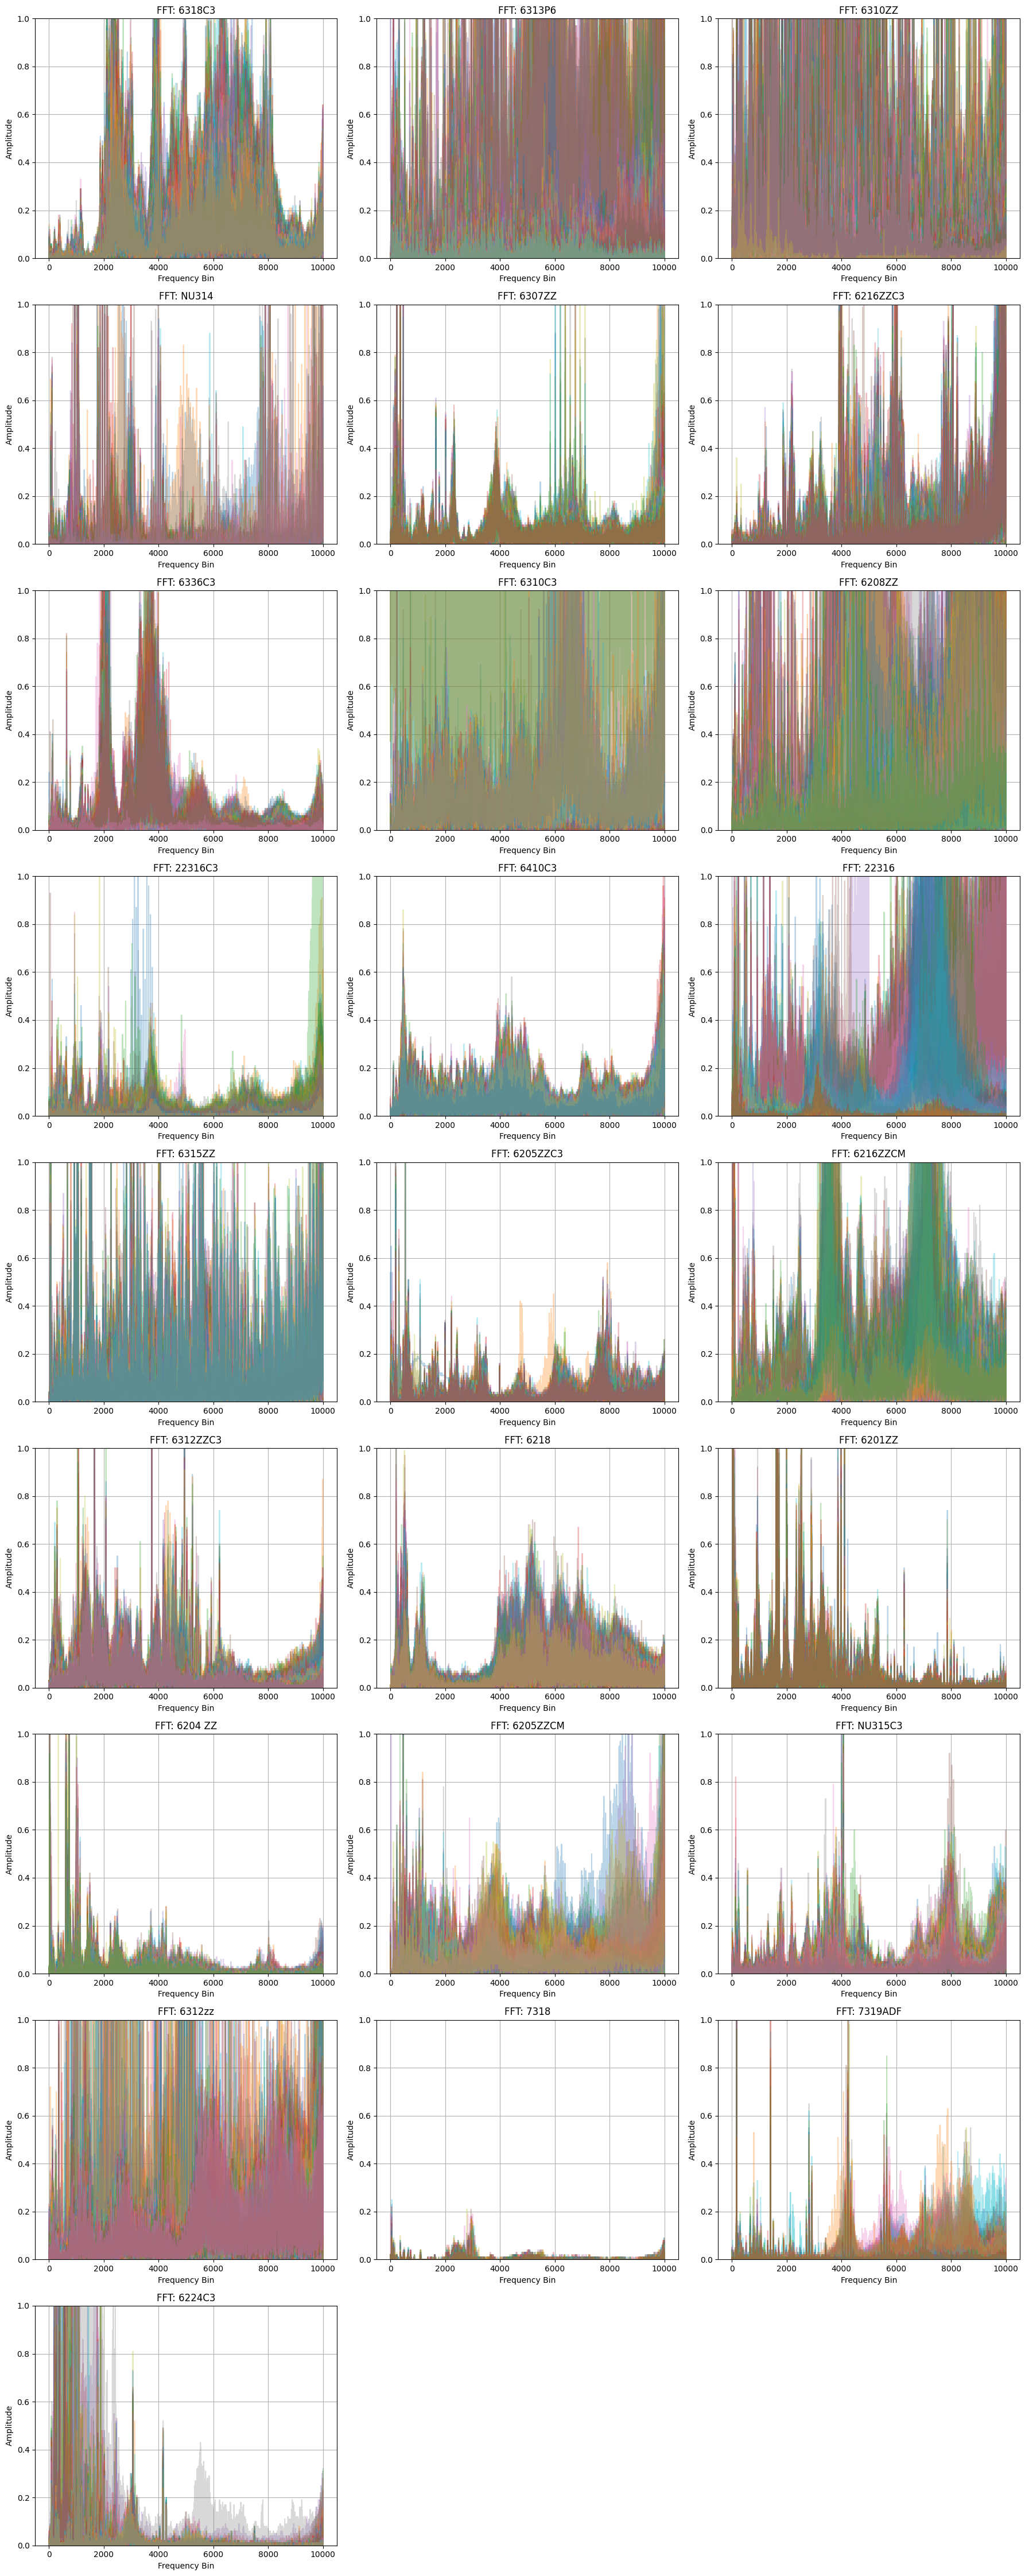

In [25]:

start_rank = 0   #
end_rank = 25    # 

# 指定範囲のValueを取得
target_values = summary_df.iloc[start_rank:end_rank]['Value'].tolist()

# グリッド設定
n_cols = 3  # 横の列数
n_rows = math.ceil(len(target_values) / n_cols)  # 行数は自動計算

# プロットの枠を作成
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axs = axs.flatten()  # 二次元から一次元に変換して使いやすく

# 各Valueごとにサブプロット
for idx, value in enumerate(target_values):
    fft_list = summary_df[summary_df['Value'] == value]['fftdatax'].values

    if len(fft_list) > 0:
        fft_data = fft_list[0]

        # 文字列から数値配列に変換
        fft_arrays = [np.array(list(map(float, item.split(',')))) for item in fft_data]

        ax = axs[idx]

        # 各波形を重ねて描画
        for arr in fft_arrays:
            ax.plot(arr, alpha=0.3)

        ax.set_title(f'FFT: {value}')
        ax.set_xlabel('Frequency Bin')
        ax.set_ylabel('Amplitude')
        ax.grid(True)
        # 縦軸の範囲を設定
        ax.set_ylim(0, 1)
    else:
        print(f"Value {value} は存在しません。")

# 使わなかった余分な枠を消す
for idx in range(len(target_values), len(axs)):
    fig.delaxes(axs[idx])

plt.tight_layout()
plt.show()


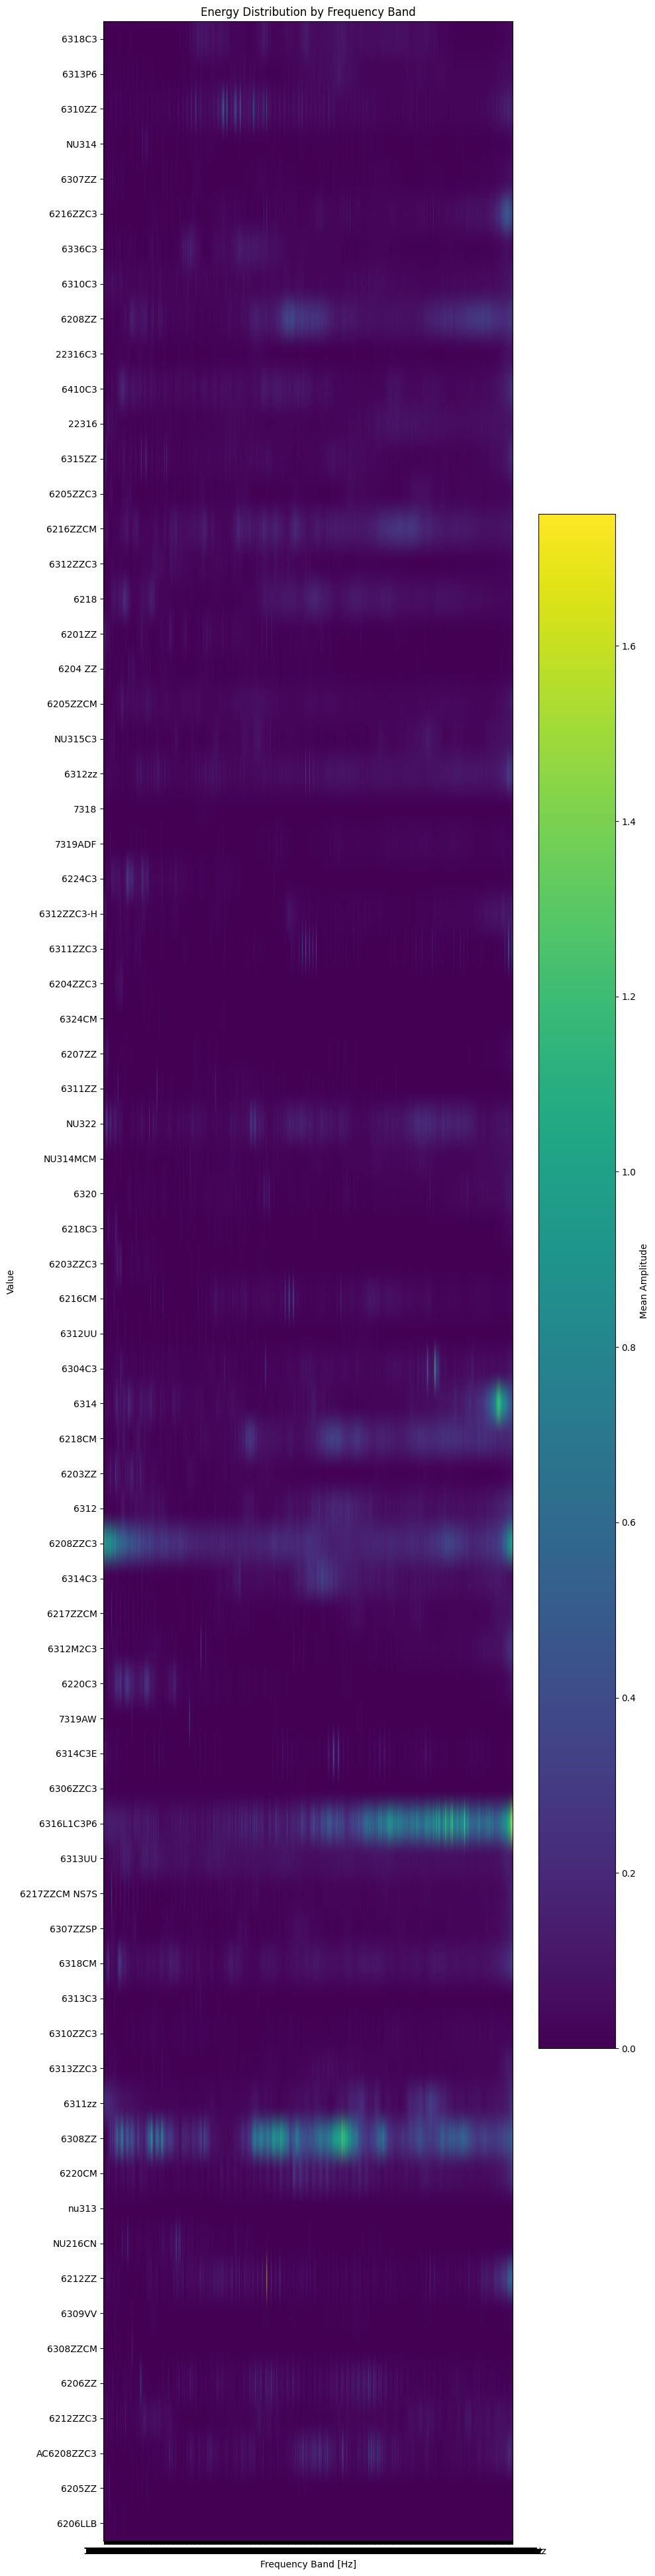

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# パラメータ設定
freq_min = 8        # 最小周波数
freq_max = 10000    # 最大周波数
freq_resolution = 1 # 分解能1Hz
n_bins = 1000        # 分割

# 周波数軸
freqs = np.arange(freq_min, freq_max + 1, freq_resolution)

# ビンの境界
bins = np.linspace(freq_min, freq_max, n_bins + 1)

# 出力結果
energy_results = []

for value in summary_df['Value']:
    fft_list = summary_df[summary_df['Value'] == value]['fftdatax'].values

    if len(fft_list) > 0:
        fft_data = fft_list[0]

        fft_arrays = []

        for item in fft_data:
            if isinstance(item, str):
                arr = np.array(list(map(float, item.strip('[]').split(','))))
            elif isinstance(item, (list, np.ndarray)):
                arr = np.array(item)
            else:
                continue

            fft_arrays.append(arr)

        if len(fft_arrays) == 0:
            continue

        fft_mean = np.mean(fft_arrays, axis=0)

        # データの長さに応じてfreqsを調整
        fft_length = len(fft_mean)
        freqs_current = np.arange(freq_min, freq_min + fft_length)

        # 各周波数ビンごとの平均エネルギー
        energy_bins = []

        for i in range(n_bins):
            start_freq = bins[i]
            end_freq = bins[i + 1]

            # 該当するインデックス
            idx = np.where((freqs_current >= start_freq) & (freqs_current < end_freq))[0]

            if len(idx) > 0:
                bin_mean = np.mean(fft_mean[idx])
            else:
                bin_mean = 0

            energy_bins.append(bin_mean)

        energy_results.append({
            'Value': value,
            'Energy': energy_bins
        })

# DataFrame化
energy_df = pd.DataFrame(energy_results)
energy_matrix = np.vstack(energy_df['Energy'].values)

# ヒートマップ表示
plt.figure(figsize=(10, len(energy_df) * 0.5 + 3))
plt.imshow(energy_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Amplitude')

plt.yticks(np.arange(len(energy_df)), energy_df['Value'])
plt.xticks(np.arange(n_bins), [f'{int(bins[i])}-{int(bins[i+1])}Hz' for i in range(n_bins)])

plt.title('Energy Distribution by Frequency Band')
plt.xlabel('Frequency Band [Hz]')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


In [26]:
# 前処理（必須）
final_df['Value'] = final_df['Value'].astype(str).str.replace(' ', '').str.upper()
target_value = str(6320).replace(' ', '').upper()

# sensorid取得
sensor_ids = final_df[final_df['Value'] == target_value]['sensorid'].dropna().unique().tolist()

if len(sensor_ids) == 1:
    sensorid = sensor_ids[0]
    print(f"✅ Value = {target_value} に対応する sensorid = {sensorid}")

    # speed取得
    speed_value = merged_df.loc[merged_df['SensorId'] == sensorid, 'speed'].dropna().unique()

    if len(speed_value) == 1:
        speed = float(speed_value[0])  # ← ★文字列→数値に変換
        print(f"⚙️  sensorid = {sensorid} の回転数（speed） = {speed}")

        # 🔍 特徴周波数の計算ここに追加
        import numpy as np

        # 軸受パラメータ（例：6320）
        N = 8          # 玉の数
        d = 30         # 玉径 [mm]
        D = 157.5      # ピッチ円径 [mm]
        theta = 0      # 接触角 [度]

        fr = speed / 60  # 回転数をHzに変換
        cos_theta = np.cos(np.radians(theta))

        BPFO = (N / 2) * (1 + (d / D) * cos_theta) * fr
        BPFI = (N / 2) * (1 - (d / D) * cos_theta) * fr
        BSF = (D / (2 * d)) * (1 - ((d / D) * cos_theta) ** 2) * fr
        FTF = (1 / 2) * (1 - (d / D) * cos_theta) * fr

        # 出力
        print(f"\n🔍軸受型番：{target_value} の特徴周波数:")
        
        print(f"回転数 : {fr:.2f} Hz")
        print(f"BPFO (外輪) : {BPFO:.2f} Hz")
        print(f"BPFI (内輪) : {BPFI:.2f} Hz")
        print(f"BSF (玉)    : {BSF:.2f} Hz")
        print(f"FTF (保持器): {FTF:.2f} Hz")

    elif len(speed_value) == 0:
        print("⚠️ speed が見つかりませんでした（NaN）")
    else:
        print(f"⚠️ 複数の speed が存在します: {speed_value.tolist()}")

    # FFTデータ抽出
    fft_df = final_df.loc[final_df['sensorid'] == sensorid, ['sensorid', 'fftrecord_date', 'fftdatax']].dropna()

    fft_df = fft_df.reset_index(drop=True)
    fft_df.index = fft_df.index + 1

    print("\n🎯 抽出されたFFTデータ:")
    print(fft_df)

else:
    print("❌ 対応する sensorid が1件ではありません。処理をスキップします。")


✅ Value = 6320 に対応する sensorid = VC000574
⚙️  sensorid = VC000574 の回転数（speed） = 985.0

🔍軸受型番：6320 の特徴周波数:
回転数 : 16.42 Hz
BPFO (外輪) : 78.17 Hz
BPFI (内輪) : 53.16 Hz
BSF (玉)    : 41.53 Hz
FTF (保持器): 6.64 Hz

🎯 抽出されたFFTデータ:
    sensorid       fftrecord_date  \
1   VC000574  2021-09-03T06:57:58   
2   VC000574  2021-09-10T06:57:54   
3   VC000574  2021-09-17T06:57:08   
4   VC000574  2021-09-24T06:56:49   
5   VC000574  2021-10-15T06:56:18   
..       ...                  ...   
70  VC000574  2025-02-10T11:22:28   
71  VC000574  2025-03-10T11:20:35   
72  VC000574  2025-04-07T11:19:08   
73  VC000574  2025-04-28T11:17:18   
74  VC000574  2025-06-02T11:15:56   

                                             fftdatax  
1   0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...  
2   0.03,0,0,0,0,0,0,0.01,0,0,0,0,0.02,0.11,0.12,0...  
3   0.02,0,0,0,0,0,0.07,0.13,0.05,0,0,0,0.03,0.07,...  
4   0.02,0,0,0,0,0,0.02,0.03,0.01,0,0,0.01,0.03,0....  
5   0.01,0,0.01,0,0,0,0,0,0,0,0,0,0,0.01,0.01,0.01...  


In [27]:

df2=df["fftdatax"].str.split(',',expand=True)
df2=df2.astype(float)

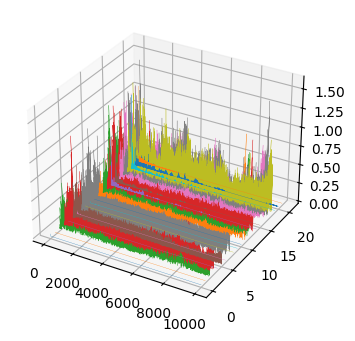

In [28]:
fig=plt.figure(figsize=(20,4),dpi=100)
ax=plt.axes(projection="3d")

for i in range(len(df2)):
    ax.plot(np.arange(10000),df2.iloc[i][0:10000],i,zdir='y',linewidth=0.2)


In [29]:
len(df2)

22

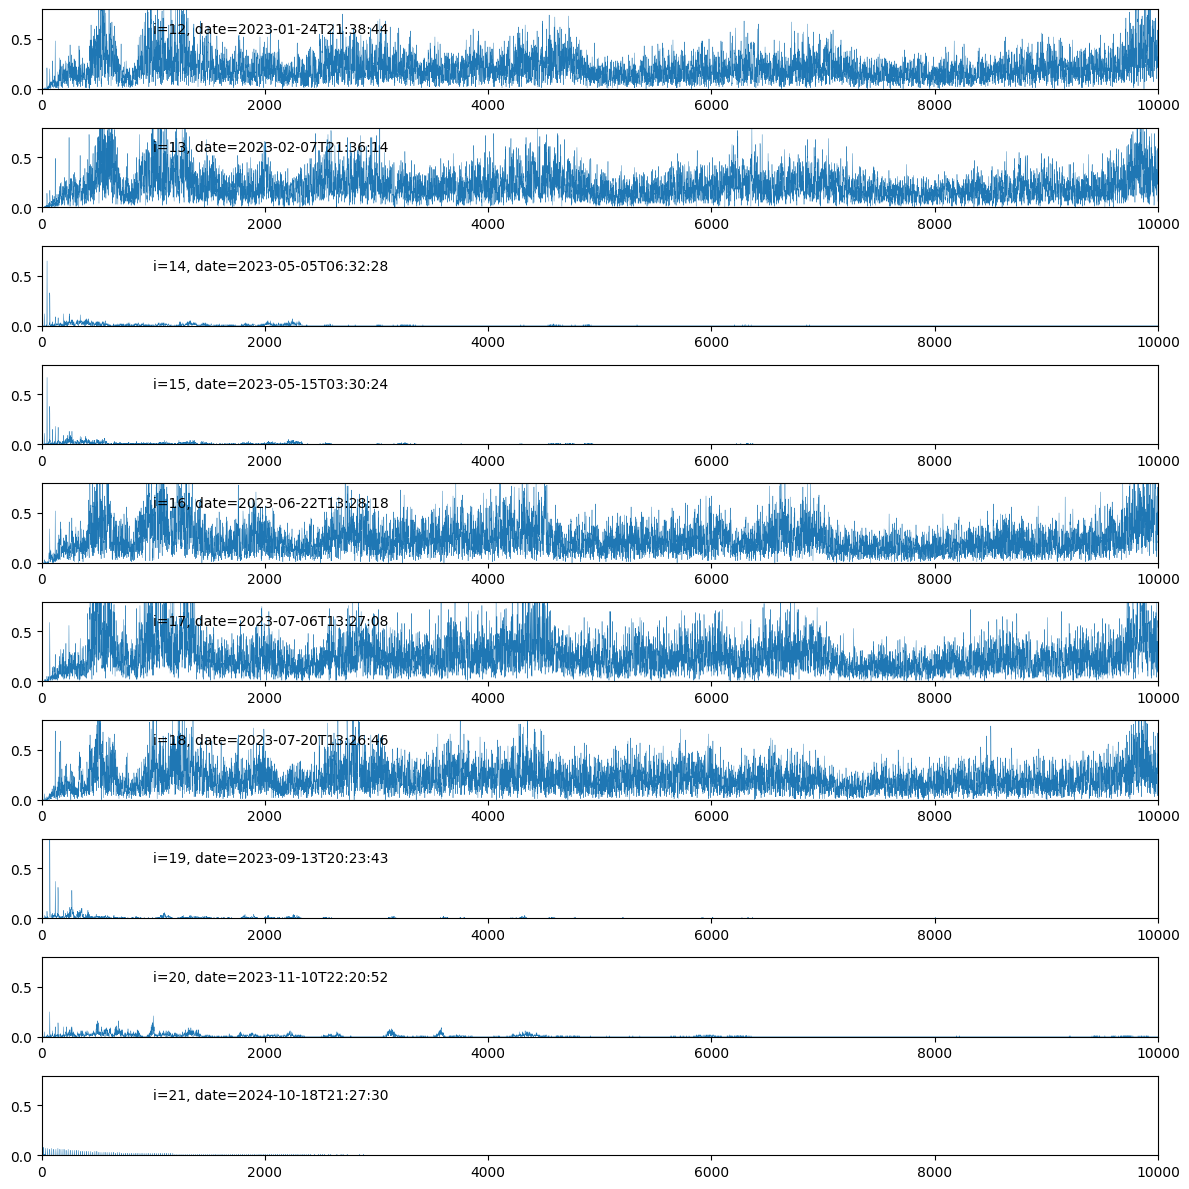

In [30]:
k = len(df) - 10
datacount = 10  # 
start_idx = k
end_idx = start_idx + datacount

# 実データ数に応じてスライス
df2_sub = df2.iloc[start_idx:end_idx]
df_sub = df.iloc[start_idx:end_idx]

# 実際に取得できた行数に合わせて描画数を調整
actual_count = len(df2_sub)

if actual_count == 0:
    print(f"No data found in df2 from index {start_idx} to {end_idx}.")
else:
    fig_height = actual_count * 1.2
    fig, ax = plt.subplots(actual_count, 1, figsize=(12, fig_height), dpi=100)

    # サブプロットが1つだけのとき、axはリストでなくAxesSubplotオブジェクトになる → 一律リスト化
    if actual_count == 1:
        ax = [ax]

    startf = 0
    endf = 10000

    for k in range(actual_count):
        orig_idx = df2_sub.index[k]
        ax[k].plot(np.arange(startf, endf), df2_sub.iloc[k][startf:endf], linewidth=0.3)
        ax[k].set_ylim(0, 0.8)
        ax[k].text(0.1, 0.7, f"i={orig_idx}, date={df_sub['fftrecord_date'].iloc[k]}", transform=ax[k].transAxes)
        ax[k].set_xlim(startf, endf)

    fig.tight_layout()
    plt.show()


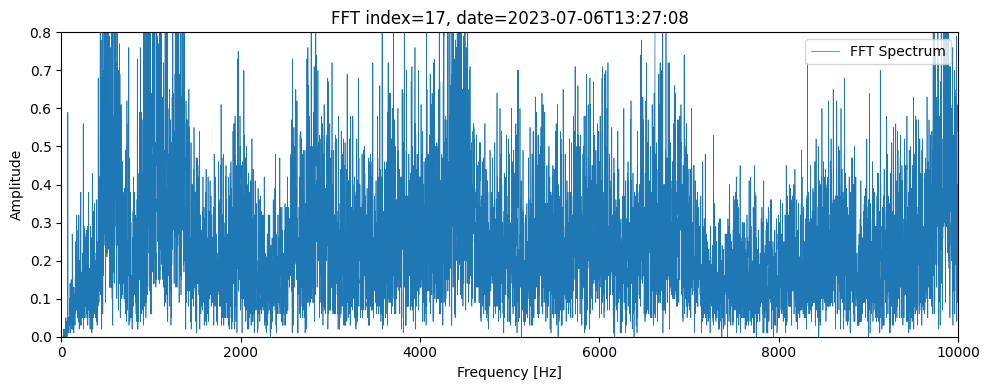

In [31]:
# 表示したいインデックス番号
k = len(df) - 5  # 最新から5番目

# 周波数範囲
startf = 0
endf = 10000

plt.figure(figsize=(10, 4), dpi=100)
plt.plot(np.arange(startf, endf), df2.iloc[k][startf:endf], linewidth=0.5, label='FFT Spectrum')
plt.ylim(0, 0.8)
plt.xlim(startf, endf)
plt.title(f"FFT index={k}, date={df['fftrecord_date'][k]}")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()



In [32]:
import numpy as np
import pandas as pd

freq_min = 8
freq_max = 9999

startf = freq_min
endf = freq_max + 1  # Pythonスライスは終端を含まない

amplitudes = df2.iloc[k][startf:endf].values
frequencies = np.arange(startf, endf)

window = 5  # 区間幅

# 区間リスト作成
blocks = []
for base in range(startf, endf, window):
    mask = (frequencies >= base) & (frequencies < base + window)
    if not np.any(mask):
        continue
    idx_within_block = np.where(mask)[0]
    max_idx_in_block = idx_within_block[np.argmax(amplitudes[mask])]
    blocks.append(max_idx_in_block)

# Freq1, Freq2のすべての代表ペアを作る
diff_list = []
for i in blocks:
    for j in blocks:
        if i == j:
            continue

        freq1 = frequencies[i]
        freq2 = frequencies[j]
        amp1 = amplitudes[i]
        amp2 = amplitudes[j]

        freq_diff = abs(freq1 - freq2)

        # 5Hz以上かつ1000Hz未満の差を持つペアのみを対象にする
        if freq_diff < 5 or freq_diff >= 500:
            continue

        score = amp1 + amp2

        diff_list.append({
            "Freq1": freq1,
            "Amp1": amp1,
            "Freq2": freq2,
            "Amp2": amp2,
            "FreqDiff": freq_diff,
            "Score": score
        })

diff_df = pd.DataFrame(diff_list)



In [33]:
diff_df_sorted = diff_df.sort_values("Score", ascending=False).reset_index(drop=True)
diff_df_sorted.head(20)#Score順


,Freq1,Amp1,Freq2,Amp2,FreqDiff,Score
0,1282,1.63,1309,1.32,27,2.95
1,1309,1.32,1282,1.63,27,2.95
2,1282,1.63,983,1.28,299,2.91
3,983,1.28,1282,1.63,299,2.91
4,9883,1.54,9894,1.34,11,2.88
5,9894,1.34,9883,1.54,11,2.88
6,1282,1.63,1244,1.23,38,2.86
7,1244,1.23,1282,1.63,38,2.86
8,1028,1.15,1282,1.63,254,2.78
9,1282,1.63,1028,1.15,254,2.78


In [34]:
agg_df = diff_df.groupby("FreqDiff")["Score"].sum().reset_index()
mean_df = diff_df.groupby("FreqDiff")["Score"].mean().reset_index()

# 2. カラム名を見やすく
agg_df.columns = ["FreqDiff", "ScoreSum"]
mean_df.columns = ["FreqDiff", "Scoremean"]

# 3. 結果を確認
agg_df


,FreqDiff,ScoreSum
0,5,580.02
1,6,704.38
2,7,695.42
3,8,649.98
4,9,675.60
...,...,...
490,495,603.90
491,496,602.94
492,497,579.12
493,498,661.62


In [35]:
# 大きい順に並べ替え
agg_df_sorted = agg_df.sort_values("ScoreSum", ascending=False).reset_index(drop=True)
mean_df_sorted = mean_df.sort_values("Scoremean", ascending=False).reset_index(drop=True)

agg_df_sorted.head(20)


,FreqDiff,ScoreSum
0,25,738.66
1,48,736.28
2,75,727.66
3,291,721.12
4,185,720.56
5,201,719.84
6,181,718.14
7,110,717.78
8,211,715.70
9,266,715.36


In [36]:
mean_df_sorted.head(20)

,FreqDiff,Scoremean
0,241,0.870228
1,401,0.860625
2,160,0.860398
3,268,0.859726
4,383,0.859509
5,203,0.855596
6,262,0.854080
7,191,0.853909
8,175,0.853762
9,376,0.853641


In [37]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# === 特徴量保存用リスト ===
features = []

# === 1行ずつ処理してリストに追加 ===
for i, row in final_df.iterrows():
    try:
        arr = np.array(list(map(float, row['fftdatax'].split(','))))
        power_spectrum = arr ** 2
        norm_ps = power_spectrum / (np.sum(power_spectrum) + 1e-8)
        N = len(arr)
        freqs = np.arange(N)

        basic = {
            'mean': np.mean(arr),
            'std': np.std(arr),
            'max': np.max(arr),
            'min': np.min(arr),
            'median': np.median(arr),
            'peak_ratio': np.max(arr) / (np.mean(arr) + 1e-8),
            'energy': np.sum(arr**2),
        }

        spectral = {
            'spectral_centroid': np.sum(freqs * power_spectrum) / (np.sum(power_spectrum) + 1e-8),
            'spectral_entropy': entropy(norm_ps),
            'spectral_flatness': np.exp(np.mean(np.log(arr + 1e-8))) / (np.mean(arr) + 1e-8),
            'low_freq_energy': np.sum(power_spectrum[:N//3]),
            'mid_freq_energy': np.sum(power_spectrum[N//3:2*N//3]),
            'high_freq_energy': np.sum(power_spectrum[2*N//3:])
        }

        feature_row = {
            'sensorid': row['sensorid'],
            'ModelCode': row['ModelCode'],
            'Model': row['Model'],
            'fftrecord_date': row['fftrecord_date'],
            **basic,
            **spectral
        }

        features.append(feature_row)

        if i % 500 == 0:
            print(f"{i} rows processed...")

    except Exception as e:
        print(f"Error processing row {i}: {e}")




Error processing row 0: 'ModelCode'
Error processing row 1: 'ModelCode'
Error processing row 2: 'ModelCode'
Error processing row 3: 'ModelCode'
Error processing row 4: 'ModelCode'
Error processing row 5: 'ModelCode'
Error processing row 6: 'ModelCode'
Error processing row 7: 'ModelCode'
Error processing row 8: 'ModelCode'
Error processing row 9: 'ModelCode'
Error processing row 10: 'ModelCode'
Error processing row 11: 'ModelCode'
Error processing row 12: 'ModelCode'
Error processing row 13: 'ModelCode'
Error processing row 14: 'ModelCode'
Error processing row 15: 'ModelCode'
Error processing row 16: 'ModelCode'
Error processing row 17: 'ModelCode'
Error processing row 18: 'ModelCode'
Error processing row 19: 'ModelCode'
Error processing row 20: 'ModelCode'
Error processing row 21: 'ModelCode'
Error processing row 22: 'ModelCode'
Error processing row 23: 'ModelCode'
Error processing row 24: 'ModelCode'
Error processing row 25: 'ModelCode'
Error processing row 26: 'ModelCode'
Error proce

In [38]:
feature_df

NameError: name 'feature_df' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# === ModelCode 1〜9 を抽出 ===
mask_model_1_to_9 = final_df["ModelCode"].isin(range(1, 10))
features_subset = feature_df[mask_model_1_to_9]
modelcode_subset = final_df.loc[mask_model_1_to_9, "ModelCode"]

# === 数値列のみ抽出し、NaNを除外 ===
numerical_features = features_subset.select_dtypes(include=["number"])
numerical_features_clean = numerical_features.dropna()
modelcode_clean = modelcode_subset[numerical_features_clean.index]

# === スケーリングとPCA ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_features_clean)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# === PCA結果をDataFrameにまとめる ===
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["ModelCode"] = modelcode_clean.values

# === サブプロット (3×3グリッド) ===
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle("ModelCode 1~9 のFFT特徴（PCA）", fontsize=16)

# パレットを固定（ModelCodeの値が1〜9のときのみ有効）
palette = sns.color_palette("tab10", n_colors=9)
color_map = {code: palette[i] for i, code in enumerate(range(1, 10))}

for idx, code in enumerate(range(1, 10)):
    ax = axes[idx // 3, idx % 3]
    subset = pca_df[pca_df["ModelCode"] == code]
    
    if not subset.empty:
        ax.scatter(
            subset["PC1"], 
            subset["PC2"], 
            color=color_map[code], 
            alpha=0.7
        )
        ax.set_title(f"ModelCode {code}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True)
    else:
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


KeyError: 'ModelCode'

In [ ]:
numerical_features_clean 

,ModelCode,mean,std,max,min,median,peak_ratio,energy,spectral_centroid,spectral_entropy,spectral_flatness,low_freq_energy,mid_freq_energy,high_freq_energy
1,2,0.000149,0.001345,0.03,0.0,0.00,201.328770,0.0183,672.502365,4.660049,0.000081,0.0183,0.0000,0.0000
2,2,0.005416,0.012075,0.43,0.0,0.00,79.394240,1.7514,4919.621532,6.148217,0.000255,0.4741,0.6135,0.6638
3,2,0.001409,0.003925,0.05,0.0,0.00,35.485909,0.1739,5143.167042,6.881549,0.000041,0.0448,0.0529,0.0762
4,2,0.004851,0.011682,0.44,0.0,0.00,90.702761,1.5999,4909.170230,5.746624,0.000215,0.3780,0.6433,0.5786
7,1,0.001049,0.005478,0.08,0.0,0.00,76.262381,0.3111,2130.833104,5.451153,0.000021,0.3056,0.0055,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28102,5,0.000030,0.000599,0.02,0.0,0.00,666.444518,0.0036,283.082547,3.121421,0.000346,0.0035,0.0000,0.0001
28103,5,0.000013,0.000387,0.02,0.0,0.00,1537.279016,0.0015,93.266045,2.338372,0.000782,0.0015,0.0000,0.0000
28104,5,0.025078,0.167625,12.24,0.0,0.01,488.077005,287.2702,5135.094229,2.010369,0.016841,12.3139,273.6823,1.2740
28105,5,0.023929,0.122194,7.93,0.0,0.01,331.396911,155.0399,4907.149425,2.382916,0.031050,15.1072,137.8215,2.1112


In [ ]:
from sklearn.ensemble import IsolationForest

# Isolation Forest による異常検出
iso_model = IsolationForest(contamination=0.03, random_state=42)
anomaly_labels = iso_model.fit_predict(X_scaled)  # -1: 異常, 1: 正常

# 結果をpca_dfに追加
pca_df["anomaly"] = anomaly_labels  # -1 or 1


C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\2149399326.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(outlier["PC1"], outlier["PC2"], color='red', edgecolors='black', marker='x', s=50, label='anomaly')
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\2149399326.py:31: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\2149399326.py:31: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\2149399326.py:31: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Te

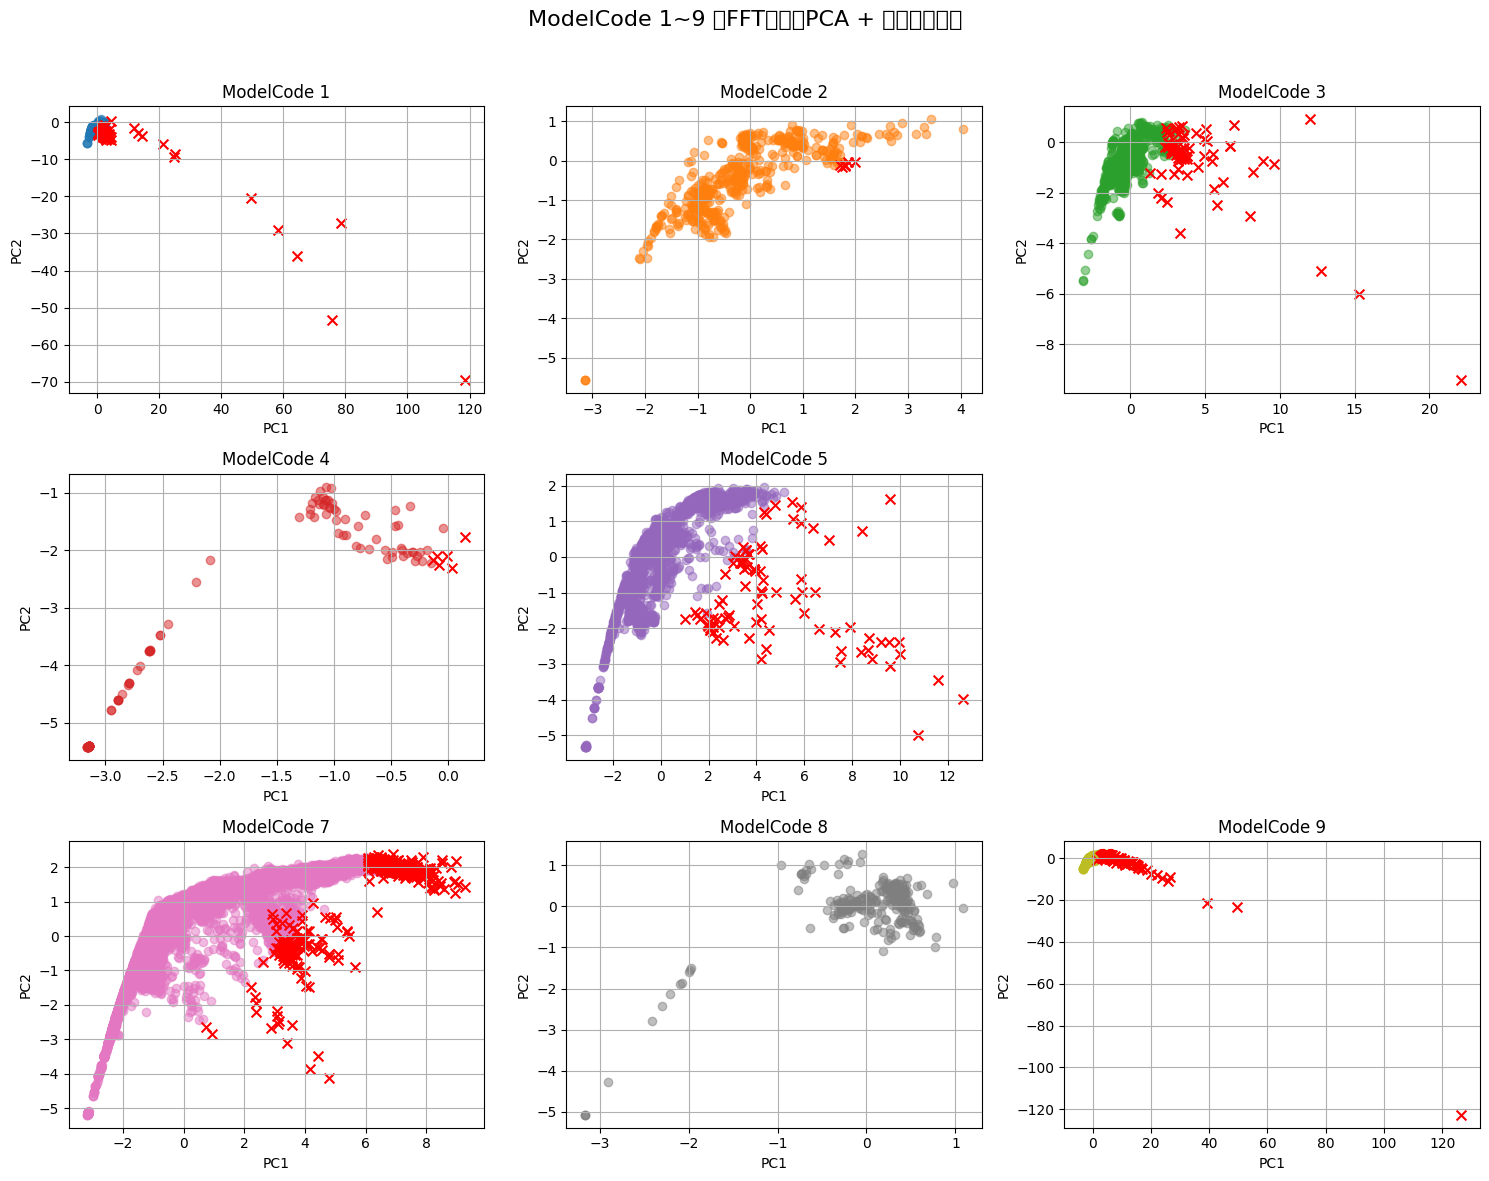

In [ ]:
# 再描画：ModelCode 1〜9 ごとのグリッド（異常点は赤）

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle("ModelCode 1~9 のFFT特徴（PCA + 異常点表示）", fontsize=16)

# カラーマップ：正常点はModelCode色、異常点は赤
palette = sns.color_palette("tab10", n_colors=9)
color_map = {code: palette[i] for i, code in enumerate(range(1, 10))}

for idx, code in enumerate(range(1, 10)):
    ax = axes[idx // 3, idx % 3]
    subset = pca_df[pca_df["ModelCode"] == code]
    
    if not subset.empty:
        normal = subset[subset["anomaly"] == 1]
        outlier = subset[subset["anomaly"] == -1]

        # 正常点
        ax.scatter(normal["PC1"], normal["PC2"], alpha=0.5, color=color_map[code], label='normal')

        # 異常点（赤で目立たせる）
        ax.scatter(outlier["PC1"], outlier["PC2"], color='red', edgecolors='black', marker='x', s=50, label='anomaly')

        ax.set_title(f"ModelCode {code}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True)
    else:
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\781947110.py:26: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\781947110.py:26: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\781947110.py:26: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\781947110.py:26: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\AppData\Local\Temp\ipykernel_21432\781947110.py:26: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\H6445\

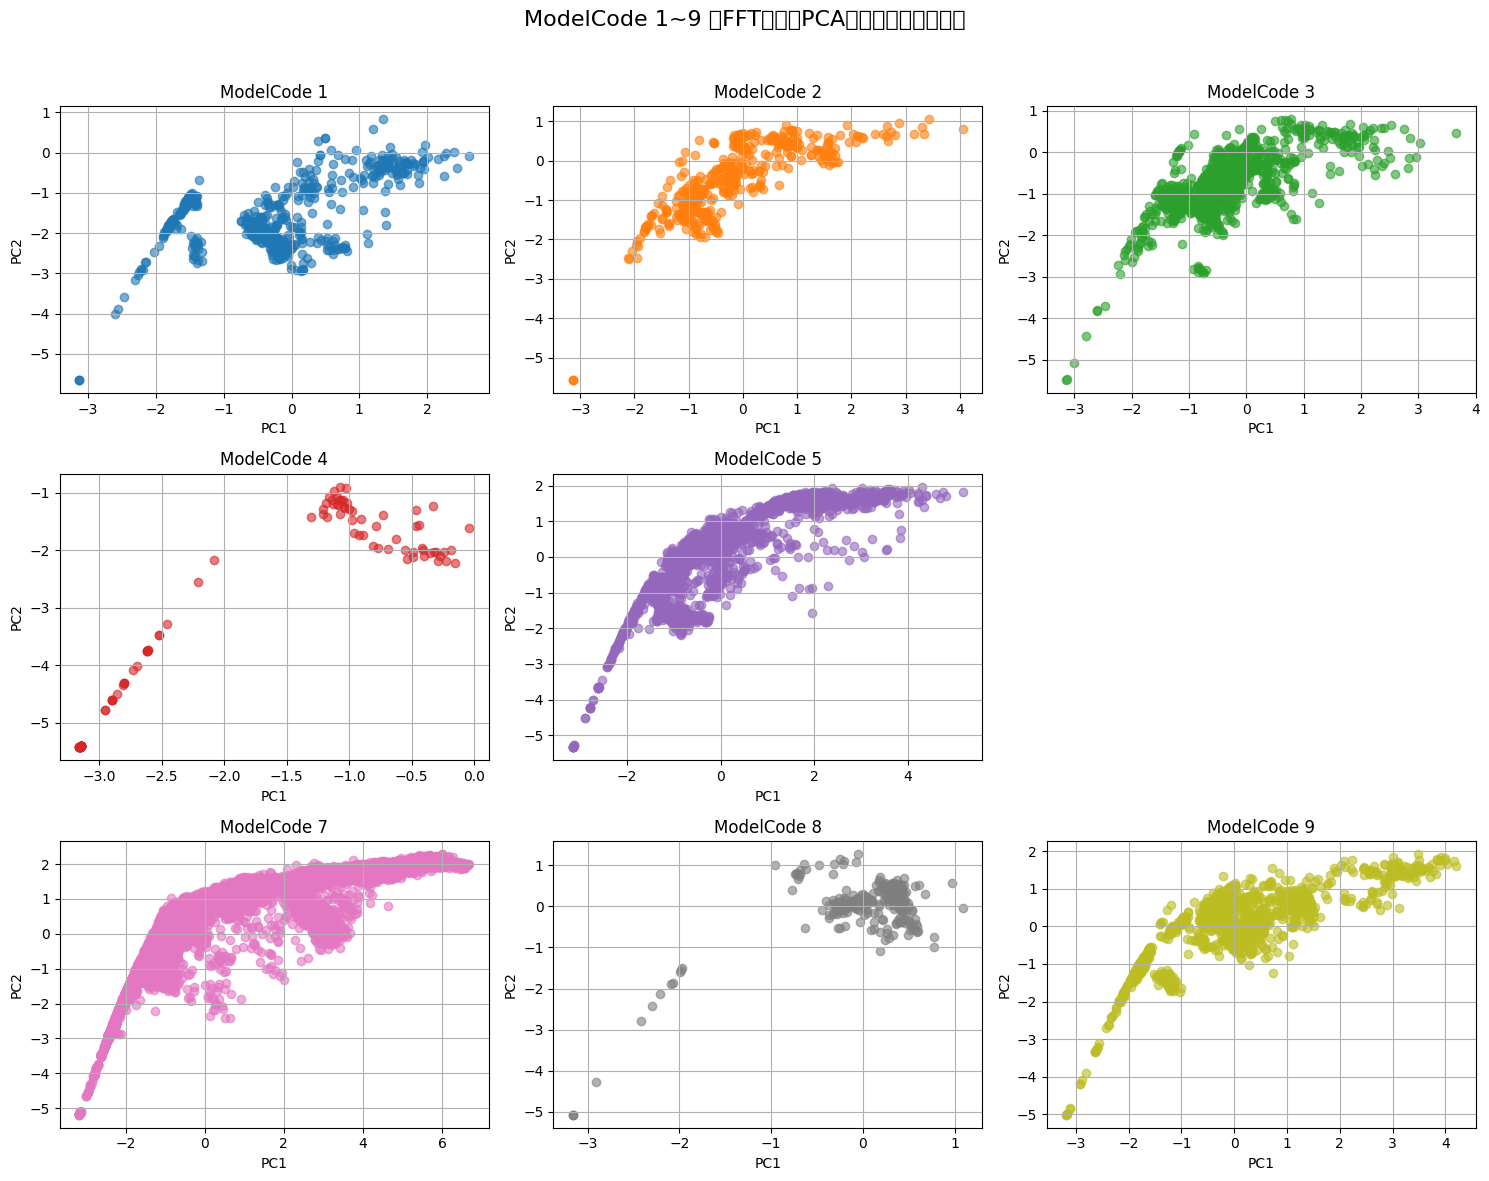

In [ ]:
# 正常データ（anomaly == 1）だけを抽出
normal_df = pca_df[pca_df["anomaly"] == 1]

# グリッドプロット（3x3）
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle("ModelCode 1~9 のFFT特徴（PCA・正常データのみ）", fontsize=16)

# カラーマップ（ModelCodeごとの色）
palette = sns.color_palette("tab10", n_colors=9)
color_map = {code: palette[i] for i, code in enumerate(range(1, 10))}

# 各モデルごとに描画
for idx, code in enumerate(range(1, 10)):
    ax = axes[idx // 3, idx % 3]
    subset = normal_df[normal_df["ModelCode"] == code]

    if not subset.empty:
        ax.scatter(subset["PC1"], subset["PC2"], color=color_map[code], alpha=0.6)
        ax.set_title(f"ModelCode {code}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True)
    else:
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# === ModelCode 1〜9 を抽出 ===
mask_model_1_to_9 = final_df["ModelCode"].isin(range(1, 10))
features_subset = feature_df[mask_model_1_to_9]
modelcode_subset = final_df.loc[mask_model_1_to_9, "ModelCode"]

# === 数値列のみ抽出し、NaNを除外 ===
numerical_features = features_subset.select_dtypes(include=["number"])
numerical_features_clean = numerical_features.dropna()
modelcode_clean = modelcode_subset[numerical_features_clean.index]

# === スケーリングとPCA（3次元） ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_features_clean)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

# === PCA結果をDataFrameにまとめる ===
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"])
pca_df["ModelCode"] = modelcode_clean.values.astype(str)

# === 3x3 のサブプロットレイアウト（3D用） ===
fig = make_subplots(
    rows=3, cols=3,
    specs=[[{'type': 'scene'}]*3]*3,
    subplot_titles=[f"ModelCode {i}" for i in range(1, 10)]
)

# === 各ModelCodeに対応する3D散布図を各サブプロットに描画 ===
for i, code in enumerate(range(1, 10)):
    subset = pca_df[pca_df["ModelCode"] == str(code)]
    row = i // 3 + 1
    col = i % 3 + 1

    if not subset.empty:
        scatter = go.Scatter3d(
            x=subset["PC1"],
            y=subset["PC2"],
            z=subset["PC3"],
            mode='markers',
            marker=dict(size=3, opacity=0.7),
            name=f"ModelCode {code}",
            showlegend=False
        )
        fig.add_trace(scatter, row=row, col=col)

# === レイアウト調整 ===
fig.update_layout(
    height=1000, width=1000,
    title_text="ModelCode 1~9 のFFT特徴（PCA 3次元 - 3×3回転可能表示）",
    margin=dict(l=0, r=0, b=0, t=50)
)

# 各subplotに軸ラベルを設定
for i in range(1, 10):
    scene_id = f"scene{i}"
    fig['layout'][scene_id]['xaxis']['title'] = 'PC1'
    fig['layout'][scene_id]['yaxis']['title'] = 'PC2'
    fig['layout'][scene_id]['zaxis']['title'] = 'PC3'

fig.show()


In [ ]:
from scipy.stats import zscore

# Zスコア計算
z_scores = np.abs(zscore(numerical_features_clean))

# 異常条件（Zスコアが3を超える列が1つでもある行を異常とみなす）
is_outlier = (z_scores > 3).any(axis=1)

# PCA対象データに絞る
numerical_filtered = numerical_features_clean.copy()
modelcode_filtered = modelcode_clean.copy()

# anomaly列作成（1=正常, -1=異常）
anomaly_flags = np.where(is_outlier, -1, 1)

# PCA用スケーリングと変換
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_filtered)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

# 結果データフレーム
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"])
pca_df["ModelCode"] = modelcode_filtered.values.astype(str)
pca_df["anomaly"] = anomaly_flags  # 👈 この列が必要
print(pca_df.head())



        PC1       PC2       PC3 ModelCode  anomaly
0 -1.703267 -1.408496 -0.904656         2        1
1 -1.086141 -0.288545 -0.018198         2        1
2 -1.124471 -0.013673  0.253350         2        1
3 -1.135202 -0.393851 -0.091974         2        1
4 -1.466997 -1.004833 -0.675748         1       -1


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

# === カラーマップ：ModelCodeごとに固定色 ===
palette = sns.color_palette("tab10", n_colors=9)
color_map = {str(code): f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
             for code, (r, g, b) in zip(range(1, 10), palette)}

# === 3×3の3Dサブプロット構成 ===
fig = make_subplots(
    rows=3, cols=3,
    specs=[[{'type': 'scene'}]*3]*3,
    subplot_titles=[f"ModelCode {i}" for i in range(1, 10)]
)

# === 各 ModelCode ごとに描画 ===
for i, code in enumerate(range(1, 10)):
    code_str = str(code)
    subset = pca_df[pca_df["ModelCode"] == code_str]
    row = i // 3 + 1
    col = i % 3 + 1

    if not subset.empty:
        # 正常点（anomaly == 1）
        normal = subset[subset["anomaly"] == 1]
        fig.add_trace(go.Scatter3d(
            x=normal["PC1"], y=normal["PC2"], z=normal["PC3"],
            mode='markers',
            marker=dict(size=3, color=color_map[code_str], symbol="circle", opacity=0.5),
            name=f"Model {code_str} Normal",
            showlegend=False
        ), row=row, col=col)

        # 異常点（anomaly == -1）
        outlier = subset[subset["anomaly"] == -1]
        if not outlier.empty:
            fig.add_trace(go.Scatter3d(
                x=outlier["PC1"], y=outlier["PC2"], z=outlier["PC3"],
                mode='markers',
                marker=dict(size=5, color="red", symbol="x", opacity=1.0, line=dict(width=1, color='black')),
                name=f"Model {code_str} Anomaly",
                showlegend=False
            ), row=row, col=col)
    else:
        # データが空の場合も軸だけは維持
        fig.add_trace(go.Scatter3d(
            x=[0], y=[0], z=[0],
            mode='markers',
            marker=dict(size=0.01, color='rgba(0,0,0,0)'),
            showlegend=False
        ), row=row, col=col)

# === 軸とレイアウト設定 ===
for i in range(1, 10):
    scene_id = f"scene{i}"
    fig.update_layout(**{
        scene_id: dict(
            xaxis=dict(title="PC1"),
            yaxis=dict(title="PC2"),
            zaxis=dict(title="PC3")
        )
    })

fig.update_layout(
    height=1000, width=1000,
    title="ModelCode 1〜9 のPCA 3D分布（異常点を赤×で強調, 回転可能）",
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

# === Zスコアで外れ値を検出（3以上を外れ値とみなす） ===
z_scores = np.abs(zscore(numerical_features_clean))
is_outlier = (z_scores > 3).any(axis=1)

# 外れ値を除去
numerical_filtered = numerical_features_clean[~is_outlier]
modelcode_filtered = modelcode_clean[~is_outlier]

# === スケーリングとPCA（3次元） ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_filtered)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

# === 結果をDataFrameにまとめる ===
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2", "PC3"])
pca_df["ModelCode"] = modelcode_filtered.values.astype(str)

# === カラーマップをModelCodeに固定 ===
palette = sns.color_palette("tab10", n_colors=9)
color_map = {str(code): f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
             for code, (r, g, b) in zip(range(1, 10), palette)}

# === 3×3サブプロット（回転可能な3D） ===
fig = make_subplots(
    rows=3, cols=3,
    specs=[[{'type': 'scene'}]*3]*3,
    subplot_titles=[f"ModelCode {i}" for i in range(1, 10)]
)

for i, code in enumerate(range(1, 10)):
    code_str = str(code)
    subset = pca_df[pca_df["ModelCode"] == code_str]
    row = i // 3 + 1
    col = i % 3 + 1

    if not subset.empty:
        fig.add_trace(go.Scatter3d(
            x=subset["PC1"], y=subset["PC2"], z=subset["PC3"],
            mode='markers',
            marker=dict(size=3, color=color_map[code_str], opacity=0.7),
            name=f"ModelCode {code_str}",
            showlegend=False
        ), row=row, col=col)
    else:
        # ダミーで空の透明点を描画して軸を維持
        fig.add_trace(go.Scatter3d(
            x=[0], y=[0], z=[0],
            mode='markers',
            marker=dict(size=0.01, color='rgba(0,0,0,0)'),
            showlegend=False
        ), row=row, col=col)

# === 各サブプロットの軸設定 ===
for i in range(1, 10):
    scene_id = f"scene{i}"
    fig.update_layout(**{
        scene_id: dict(
            xaxis=dict(title="PC1"),
            yaxis=dict(title="PC2"),
            zaxis=dict(title="PC3")
        )
    })

# === レイアウト ===
fig.update_layout(
    height=1000, width=1000,
    title="Zスコア法で外れ値除去後のPCA 3D分布（ModelCode 1〜9）",
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()
